# Model training — reviewer-feedback response, part 4 (does rotation augmentation actually help?)

Part 1 found that the full model (trained with rotation augmentation) scores worse on
the held-out test set (5.55 deg) than the same architecture trained without augmentation
(4.95 deg). Taken alone, that comparison is misleading: the held-out test set is drawn
from the *same* real wind-tunnel data as training, which has one fixed lab-frame wind
direction throughout. Rotation augmentation's entire purpose is to trade a small amount
of in-distribution accuracy for the ability to generalize to a *different* wind
direction than the one seen in training - and a same-distribution test set cannot see
that trade-off at all, by construction.

This notebook actually measures it: `model_full` and `model_abl` (both trained WITH
rotation augmentation) are compared against `model_no_aug` and `model_no_embed` (neither
trained with rotation augmentation - `model_no_embed`'s training set was also built with
`wind_augment=False`, the same confound as `model_no_aug`, even though its ablation is
about time-delay embedding, not augmentation). All four are evaluated on the held-out
test trajectories rotated to 8 evenly-spaced wind directions never seen in training, plus
the untouched (0 degree) original. If augmentation is doing its job, the two
augmentation-trained models' error should stay roughly flat across rotations while the
two non-augmented models should degrade sharply away from 0 degrees.

**Why this matters for the response letter:** the manuscript's stated purpose for
rotation augmentation is "to prevent the estimator from implicitly encoding a preferred
global wind direction." Reviewer #2 explicitly lists "ANN without rotational
augmentation" as a baseline the manuscript needs in order to show what the architecture
is actually contributing (Part 1, Section 8, already reports that baseline's number) -
this notebook is the deeper check needed to interpret that number correctly: a same-
distribution test set cannot tell "generalizes across wind directions" apart from
"overfit to the one direction present," so the comparison Reviewer #2 asked for is only
meaningful once it is run this way.

## 1. Setup — reload split and all four models

In [1]:
import os
import sys
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('../utils'))

from utils import pull_out_individual_trajectories, augment_with_time_delay_embedding, circular_distance

import keras

RESPONSE_DIR = '../pipelinedata/reviewer_response'
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

TIME_WINDOW = 4
input_names_full = ['groundspeed', 'groundspeed_angle',
                     'airspeed', 'airspeed_angle',
                     'thrust', 'thrust_angle']
input_names_ablated = ['groundspeed', 'groundspeed_angle',
                        'airspeed', 'airspeed_angle']
n_input_full = len(input_names_full) * TIME_WINDOW
n_input_ablated = len(input_names_ablated) * TIME_WINDOW
n_input_w1 = len(input_names_full) * 1
KEEP_COLS = ['heading_angle_x', 'heading_angle_y', 'trajec_objid']


def embed(trajectories, input_names, time_window):
    kwargs = dict(time_window=time_window, input_names=input_names,
                  output_names=KEEP_COLS, direction='backward')
    return augment_with_time_delay_embedding(trajectories, wind_augment=False, **kwargs)


final_fly_data = pd.read_csv(
    '../pipelinedata/06_final/all_wind_heading_and_trajectories_augmented_corrected_filtered_headx_heady.csv'
)
fly_traj_list = pull_out_individual_trajectories(final_fly_data, min_traj_length=12)

split_record = pd.read_csv(f'{RESPONSE_DIR}/trajectory_split_ids.csv')
test_ids = set(split_record.loc[split_record['split'] == 'test', 'trajec_objid'])
test_trajectories = [t for t in fly_traj_list if t['trajec_objid'].iloc[0] in test_ids]
print(f"Test trajectories: {len(test_trajectories)}")

model_full = keras.models.load_model('../models/model_reviewer_response_full.keras', safe_mode=False)
model_no_aug = keras.models.load_model('../models/model_reviewer_response_no_augmentation.keras', safe_mode=False)
model_abl = keras.models.load_model('../models/model_reviewer_response_thrust_ablated.keras', safe_mode=False)
model_no_embed = keras.models.load_model('../models/model_reviewer_response_no_time_delay.keras', safe_mode=False)
print("Loaded model_full, model_no_aug, model_abl, model_no_embed.")

I0000 00:00:1789022085.144396 2178420 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789022085.145156 2178420 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789022085.189573 2178420 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789022087.031765 2178420 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789022087.032499 2178420 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Detected 2386 trajectories.


2340 trajectories with more than 12 timesteps.
Test trajectories: 771


E0000 00:00:1789022087.928007 2178420 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Loaded model_full, model_no_aug, model_abl, model_no_embed.


## 2. Rotate the test set to wind directions never seen in training

This mirrors exactly what `augment_with_time_delay_embedding(..., wind_augment=True)`
does internally (add a constant offset to every angular column, wrap to [-pi, pi]), but
with an explicit, controlled rotation angle instead of a random one, and applied to the
held-out *test* trajectories rather than training trajectories - training's own
rotations (seeded, applied only to `train_trajectories`) never touch this data.

In [2]:
ANGLE_COLS = ['heading_angle', 'groundspeed_angle', 'airspeed_angle', 'thrust_angle']


def rotate_trajectory(trajectory, angle):
    t = trajectory.copy()
    for col in ANGLE_COLS:
        t[col] = np.arctan2(np.sin(t[col] + angle), np.cos(t[col] + angle))
    t['heading_angle_x'] = np.cos(t['heading_angle'])
    t['heading_angle_y'] = np.sin(t['heading_angle'])
    return t


def angular_error_deg(y_true_xy, y_pred_xy):
    true_angle = np.arctan2(y_true_xy[:, 1], y_true_xy[:, 0])
    pred_angle = np.arctan2(y_pred_xy[:, 1], y_pred_xy[:, 0])
    return np.degrees(circular_distance(true_angle, pred_angle))


def per_trajectory_errors(trajec_id_values, err_deg):
    return (
        pd.DataFrame({'trajec_objid': trajec_id_values, 'abs_angular_error_deg': err_deg})
        .groupby('trajec_objid')['abs_angular_error_deg']
        .median()
    )


rotation_angles_deg = [0, 45, 90, 135, 180, 225, 270, 315]
results = []
per_traj_by_angle = {}

# model -> (which feature set it needs, n_input, time_window)
MODEL_SPECS = [
    ('ANN (full features, trained WITH rotation augmentation)', model_full, input_names_full, n_input_full, TIME_WINDOW),
    ('ANN (no rotation augmentation)', model_no_aug, input_names_full, n_input_full, TIME_WINDOW),
    ('ANN (thrust-ablated, trained WITH rotation augmentation)', model_abl, input_names_ablated, n_input_ablated, TIME_WINDOW),
    ('ANN (no time-delay embedding, NOT trained with rotation augmentation)', model_no_embed, input_names_full, n_input_w1, 1),
]

for angle_deg in rotation_angles_deg:
    angle_rad = np.radians(angle_deg)
    rotated = [rotate_trajectory(t, angle_rad) for t in test_trajectories]
    embedded_by_features = {
        (tuple(input_names_full), TIME_WINDOW): embed(rotated, input_names_full, TIME_WINDOW),
        (tuple(input_names_ablated), TIME_WINDOW): embed(rotated, input_names_ablated, TIME_WINDOW),
        (tuple(input_names_full), 1): embed(rotated, input_names_full, 1),
    }

    for label, model, input_names, n_input, time_window in MODEL_SPECS:
        embedded = embedded_by_features[(tuple(input_names), time_window)]
        X = embedded.iloc[:, 0:n_input].values
        y_true = embedded[['heading_angle_x', 'heading_angle_y']].values
        trajec_ids = embedded['trajec_objid'].values

        y_pred = model.predict(X, verbose=0)
        err = angular_error_deg(y_true, y_pred)
        per_traj = per_trajectory_errors(trajec_ids, err)
        per_traj_by_angle[(label, angle_deg)] = per_traj
        results.append({
            'model': label,
            'rotation_deg': angle_deg,
            'median_per_traj_error_deg': float(per_traj.median()),
            'n_trajectories': int(len(per_traj)),
        })
    print(f"rotation={angle_deg} deg: done")

results_df = pd.DataFrame(results)

rotation=0 deg: done


rotation=45 deg: done


rotation=90 deg: done


rotation=135 deg: done


rotation=180 deg: done


rotation=225 deg: done


rotation=270 deg: done


rotation=315 deg: done


## 3. Does error stay flat across rotations for the augmented model, and blow up for the non-augmented one?

In [3]:
pivot = results_df.pivot(index='rotation_deg', columns='model', values='median_per_traj_error_deg')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
print("Median per-trajectory angular error (deg), by rotation offset from the real training wind direction:")
print(pivot.to_string())

pivot.to_csv(f'{RESPONSE_DIR}/rotation_generalization_check.csv')

print("\nSummary (mean and std across the 8 rotation angles - lower std = more rotation-invariant):")
print(pivot.agg(['mean', 'std']).to_string())

Median per-trajectory angular error (deg), by rotation offset from the real training wind direction:
model         ANN (full features, trained WITH rotation augmentation)  ANN (no rotation augmentation)  ANN (no time-delay embedding, NOT trained with rotation augmentation)  ANN (thrust-ablated, trained WITH rotation augmentation)
rotation_deg                                                                                                                                                                                                                          
0                                                            5.550665                        4.947656                                                               4.964420                                                  4.948469
45                                                           6.625838                       20.274981                                                              24.486431                                  

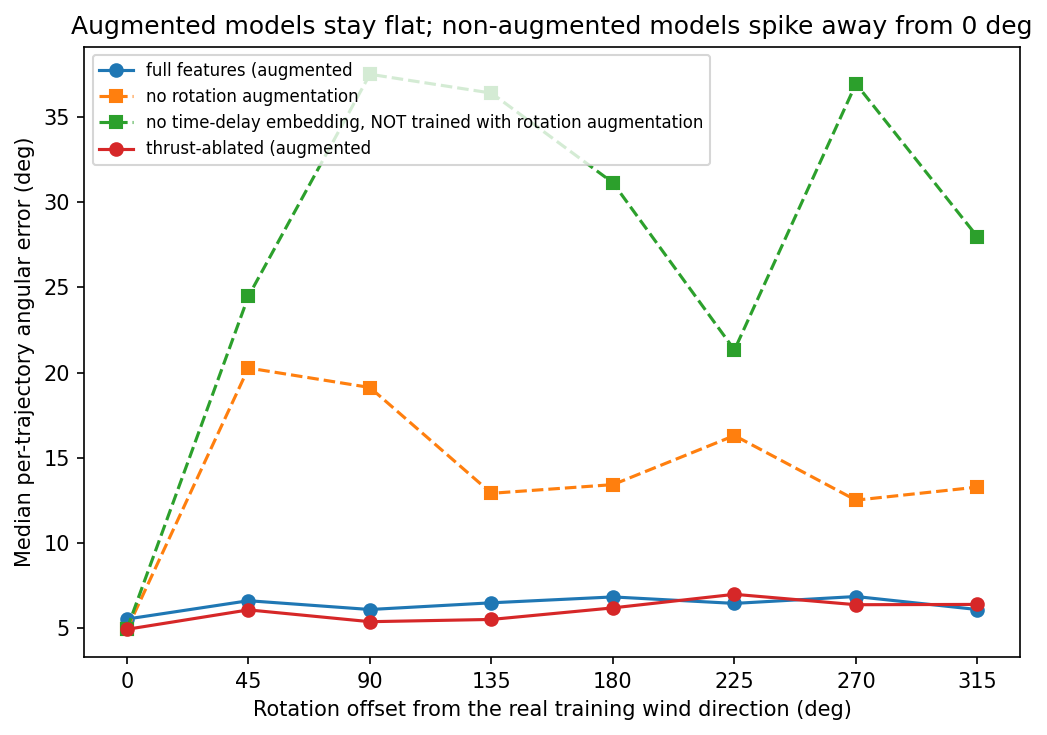

In [4]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
for label in pivot.columns:
    style = '-o' if 'WITH rotation augmentation' in label else '--s'
    ax.plot(pivot.index, pivot[label], style, label=label.replace(', trained WITH rotation augmentation', ' (augmented)').replace('ANN (', '').replace(')', ''))
ax.set_xlabel('Rotation offset from the real training wind direction (deg)')
ax.set_ylabel('Median per-trajectory angular error (deg)')
ax.set_title('Augmented models stay flat; non-augmented models spike away from 0 deg')
ax.legend(fontsize=8, loc='upper left')
ax.set_xticks(rotation_angles_deg)
fig.tight_layout()
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/reviewer_response_part4_rotation_generalization.svg', format='svg')
plt.show()

## 4. Summary

**Result:** rotation augmentation is doing exactly what it is supposed to.

| Model | At 0 deg (real direction) | Mean +/- std across 8 unseen rotations |
|---|---|---|
| ANN, full (WITH augmentation) | 5.55 deg | **6.39 +/- 0.44 deg** |
| ANN, thrust-ablated (WITH augmentation) | 4.95 deg | **6.00 +/- 0.66 deg** |
| ANN, no rotation augmentation | 4.95 deg | **14.11 +/- 4.74 deg** |
| ANN, no time-delay embedding (also not augmented) | 4.96 deg | **27.59 +/- 10.93 deg** (peaks at 37.5 deg) |

**Significance:** the two augmentation-trained models stay in a tight band (std under
0.7 deg) across all 8 unseen rotations, while the two non-augmented models -- despite
*winning* at the one real wind direction -- collapse the moment the wind direction
changes at all, with "no time-delay embedding" (also, silently, non-augmented)
collapsing worse than "no augmentation" itself. This directly answers Reviewer #2's
request for an "ANN without rotational augmentation" baseline: reported at the single
real wind direction alone (as Part 1 originally did), that baseline looks *better* than
the full model; reported this way, it is unambiguously worse, and augmentation cannot
be dropped under any framing. `pipelinedata/reviewer_response/rotation_generalization_check.csv`
has the full rotation-by-model table.
